# Importar Bibliotecas Requeridas
Importa las bibliotecas necesarias, incluyendo NumPy, Pandas, scikit-learn, XGBoost y Matplotlib.

In [1]:
# Importar Bibliotecas Requeridas
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import joblib

# Cargar y Preparar Datos
Carga el conjunto de datos desde combined_features.csv, selecciona características y objetivo, maneja valores faltantes y prepara X e y.

In [2]:
# Cargar y Preparar Datos
df = pd.read_csv('../DARA_PROC/combined_features.csv')

# Select features and target
features = ['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']
target = 'FatigueIndex'

X = df[features]
y = df[target]

# Handle missing values (if any)
X = X.fillna(X.mean())
y = y.fillna(y.mean())

# Preparar Datos para Clasificación
Divide los datos en conjuntos de entrenamiento y prueba, calcula percentiles en el objetivo de entrenamiento, categoriza el objetivo en clases (Bajo, Medio, Alto) y divide además el entrenamiento en entrenamiento y validación.

In [3]:
# Preparar Datos para Clasificación
# Primero, dividir en train y test (80% train, 20% test)
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Calcular percentiles en y_train_full
P33 = y_train_full.quantile(0.33)
P66 = y_train_full.quantile(0.66)
print(f"P33: {P33}, P66: {P66}")

# Función para categorizar
def categorize_fatigue(value, p33, p66):
    if value <= p33:
        return 0  # Bajo
    elif value <= p66:
        return 1  # Medio
    else:
        return 2  # Alto

# Categorizar y_train_full
y_train_full_cat = y_train_full.apply(lambda x: categorize_fatigue(x, P33, P66))

# Categorizar y_test usando los mismos percentiles
y_test_cat = y_test.apply(lambda x: categorize_fatigue(x, P33, P66))

# Ahora, dividir train_full en train y val (75% train, 25% val de train_full, que es 60% y 20% del total)
X_train, X_val, y_train_cat, y_val_cat = train_test_split(X_train_full, y_train_full_cat, test_size=0.25, random_state=42)

P33: -5.021884072987618, P66: -4.517375064139081


# Elegir e Inicializar Modelo Clasificador
Inicializa un XGBClassifier con parámetros especificados como n_estimators, early_stopping_rounds, eval_metric y random_state.

In [4]:
# Elegir e Inicializar Modelo Clasificador
model_clf = XGBClassifier(n_estimators=100, early_stopping_rounds=10, eval_metric='mlogloss', random_state=42)

# Entrenar el Modelo Clasificador
Ajusta el modelo clasificador en los datos de entrenamiento con conjunto de validación para parada temprana, e imprime el número de árboles usados.

In [5]:
# Entrenar el Modelo Clasificador
model_clf.fit(X_train, y_train_cat, eval_set=[(X_val, y_val_cat)], verbose=True)
print(f"Número de árboles usados: {model_clf.best_iteration + 1}")

[0]	validation_0-mlogloss:0.72022
[1]	validation_0-mlogloss:0.50678
[2]	validation_0-mlogloss:0.37070
[3]	validation_0-mlogloss:0.27965
[4]	validation_0-mlogloss:0.21668
[5]	validation_0-mlogloss:0.17300
[6]	validation_0-mlogloss:0.14176
[7]	validation_0-mlogloss:0.12041
[8]	validation_0-mlogloss:0.10515
[9]	validation_0-mlogloss:0.09462
[10]	validation_0-mlogloss:0.08709
[11]	validation_0-mlogloss:0.08176
[12]	validation_0-mlogloss:0.07850
[13]	validation_0-mlogloss:0.07562
[14]	validation_0-mlogloss:0.07355
[15]	validation_0-mlogloss:0.07321
[16]	validation_0-mlogloss:0.07221
[17]	validation_0-mlogloss:0.07291
[18]	validation_0-mlogloss:0.07250
[19]	validation_0-mlogloss:0.07340
[20]	validation_0-mlogloss:0.07290
[21]	validation_0-mlogloss:0.07278
[22]	validation_0-mlogloss:0.07339
[23]	validation_0-mlogloss:0.07413
[24]	validation_0-mlogloss:0.07452
[25]	validation_0-mlogloss:0.07517
[26]	validation_0-mlogloss:0.07575
Número de árboles usados: 17


In [6]:
# Guardar el Modelo XGBoost Clasificador
joblib.dump(model_clf, 'xgboost_classifier_model.pkl')
joblib.dump({'P33': P33, 'P66': P66}, 'xgboost_classifier_thresholds.pkl')
print("Modelo XGBoost clasificador guardado como 'xgboost_classifier_model.pkl'")
print("Umbrales de clasificación guardados como 'xgboost_classifier_thresholds.pkl'")

Modelo XGBoost clasificador guardado como 'xgboost_classifier_model.pkl'
Umbrales de clasificación guardados como 'xgboost_classifier_thresholds.pkl'


# Evaluar el Rendimiento del Modelo Clasificador
Predice en el conjunto de prueba, calcula la precisión e imprime el informe de clasificación.

In [7]:
# Evaluar el Rendimiento del Modelo Clasificador
y_pred_clf = model_clf.predict(X_test)
accuracy = accuracy_score(y_test_cat, y_pred_clf)
print(f'Precisión: {accuracy}')
print('Informe de Clasificación:')
print(classification_report(y_test_cat, y_pred_clf))

Precisión: 0.9764705882352941
Informe de Clasificación:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        81
           1       0.96      0.98      0.97        92
           2       0.98      0.99      0.98        82

    accuracy                           0.98       255
   macro avg       0.98      0.98      0.98       255
weighted avg       0.98      0.98      0.98       255



# Hacer Predicciones
Muestra predicciones de muestra, valores reales, errores y matriz de confusión.

In [8]:
# Hacer Predicciones
# Función para mapear categorías
def map_category(num):
    if num == 0:
        return "Bajo"
    elif num == 1:
        return "Medio"
    else:
        return "Alto"

# Mapear predicciones y reales
pred_mapped = [map_category(p) for p in y_pred_clf[:5]]
real_mapped = [map_category(r) for r in y_test_cat.iloc[:5].values]

print("Predicciones primeras 5:", pred_mapped)
print("Valores reales primeras 5:", real_mapped)
# Para clasificación, errores son clasificaciones incorrectas
errors_clf = y_pred_clf != y_test_cat
print("Errores (0=correcto, 1=incorrecto) primeras 5:", errors_clf.iloc[:5].values)

# Matriz de confusión
print("\nMatriz de Confusión:")
print(confusion_matrix(y_test_cat, y_pred_clf))

Predicciones primeras 5: ['Bajo', 'Medio', 'Bajo', 'Medio', 'Medio']
Valores reales primeras 5: ['Bajo', 'Medio', 'Bajo', 'Medio', 'Medio']
Errores (0=correcto, 1=incorrecto) primeras 5: [False False False False False]

Matriz de Confusión:
[[78  3  0]
 [ 0 90  2]
 [ 0  1 81]]


# Importancia de Características
Grafica e imprime las importancias de características para el modelo clasificador.

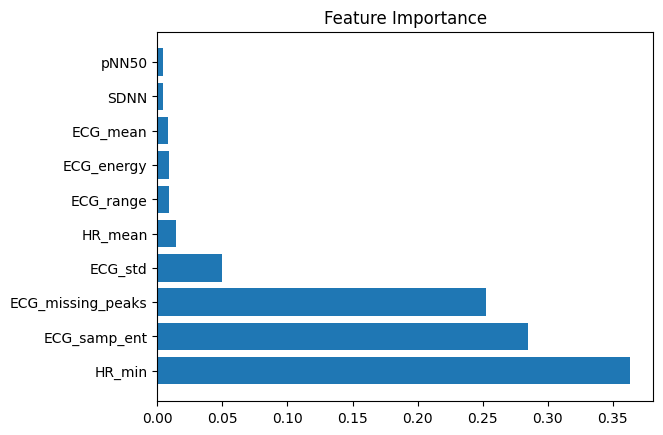

ECG_mean: 0.0079
ECG_std: 0.0496
ECG_range: 0.0093
ECG_energy: 0.0089
ECG_samp_ent: 0.2850
ECG_missing_peaks: 0.2528
SDNN: 0.0047
RMSSD: 0.0000
pNN50: 0.0045
HR_mean: 0.0142
HR_max: 0.0000
HR_min: 0.3630


In [9]:
# Importancia de Características
# Mostrar la importancia de cada característica en el modelo XGBoost Clasificador
importances_clf = model_clf.feature_importances_
feature_names = X_train.columns
# Sort for top 10
sorted_idx = np.argsort(importances_clf)[::-1][:10]
plt.barh(feature_names[sorted_idx], importances_clf[sorted_idx])
plt.title("Feature Importance")
plt.show()

# Imprimir las importancias numéricamente
for name, imp in zip(feature_names, importances_clf):
    print(f"{name}: {imp:.4f}")

# Experimento 2: Entrenamiento sin Características de HR y HRV

In [10]:
# Experimento 2: Entrenar sin características de HR y HRV
# Remover HR_mean, SDNN, RMSSD, pNN50, HR_max, HR_min de X_train, X_val, X_test
features_to_remove = ['HR_mean', 'SDNN', 'RMSSD', 'pNN50', 'HR_max', 'HR_min']
X_train_new = X_train.drop(columns=features_to_remove)
X_val_new = X_val.drop(columns=features_to_remove)
X_test_new = X_test.drop(columns=features_to_remove)

# y_train_cat, y_val_cat, y_test_cat permanecen iguales

In [11]:
# Verificar que las características se removieron correctamente
print("Características originales en X_train:", list(X_train.columns))
print("Características en X_train_new:", list(X_train_new.columns))
print("¿Se removieron las HR/HRV?", set(features_to_remove).isdisjoint(set(X_train_new.columns)))

Características originales en X_train: ['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks', 'SDNN', 'RMSSD', 'pNN50', 'HR_mean', 'HR_max', 'HR_min']
Características en X_train_new: ['ECG_mean', 'ECG_std', 'ECG_range', 'ECG_energy', 'ECG_samp_ent', 'ECG_missing_peaks']
¿Se removieron las HR/HRV? True


In [12]:
# Elegir e Inicializar Modelo Clasificador (Experimento 2)
model_clf2 = XGBClassifier(n_estimators=100, early_stopping_rounds=10, eval_metric='mlogloss', random_state=42)

In [13]:
# Entrenar el Modelo Clasificador (Experimento 2)
model_clf2.fit(X_train_new, y_train_cat, eval_set=[(X_val_new, y_val_cat)], verbose=True)
print(f"Número de árboles usados (Experimento 2): {model_clf2.best_iteration + 1}")

[0]	validation_0-mlogloss:0.72441
[1]	validation_0-mlogloss:0.51379
[2]	validation_0-mlogloss:0.38015
[3]	validation_0-mlogloss:0.29136
[4]	validation_0-mlogloss:0.23076


[5]	validation_0-mlogloss:0.18929
[6]	validation_0-mlogloss:0.16013
[7]	validation_0-mlogloss:0.13989
[8]	validation_0-mlogloss:0.12613
[9]	validation_0-mlogloss:0.11731
[10]	validation_0-mlogloss:0.11144
[11]	validation_0-mlogloss:0.10804
[12]	validation_0-mlogloss:0.10638
[13]	validation_0-mlogloss:0.10594
[14]	validation_0-mlogloss:0.10689
[15]	validation_0-mlogloss:0.10823
[16]	validation_0-mlogloss:0.11016
[17]	validation_0-mlogloss:0.11257
[18]	validation_0-mlogloss:0.11404
[19]	validation_0-mlogloss:0.11589
[20]	validation_0-mlogloss:0.11770
[21]	validation_0-mlogloss:0.11850
[22]	validation_0-mlogloss:0.11965
[23]	validation_0-mlogloss:0.12022
Número de árboles usados (Experimento 2): 14


In [14]:
# Guardar el Modelo XGBoost Clasificador (Experimento 2)
joblib.dump(model_clf2, 'xgboost_classifier_model_ablation.pkl')
print("Modelo XGBoost clasificador de ablación guardado como 'xgboost_classifier_model_ablation.pkl'")

Modelo XGBoost clasificador de ablación guardado como 'xgboost_classifier_model_ablation.pkl'


In [15]:
# Evaluar el Rendimiento del Modelo Clasificador (Experimento 2)
y_pred_clf2 = model_clf2.predict(X_test_new)
accuracy2 = accuracy_score(y_test_cat, y_pred_clf2)
print(f'Precisión (Exp2): {accuracy2}')
print('Informe de Clasificación (Exp2):')
print(classification_report(y_test_cat, y_pred_clf2))

Precisión (Exp2): 0.9764705882352941
Informe de Clasificación (Exp2):
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        81
           1       0.96      0.98      0.97        92
           2       0.98      0.99      0.98        82

    accuracy                           0.98       255
   macro avg       0.98      0.98      0.98       255
weighted avg       0.98      0.98      0.98       255



In [16]:
# Hacer Predicciones (Experimento 2)
# Mapear predicciones y reales
pred_mapped2 = [map_category(p) for p in y_pred_clf2[:5]]
real_mapped2 = [map_category(r) for r in y_test_cat.iloc[:5].values]

print("Predicciones primeras 5 (Exp2):", pred_mapped2)
print("Valores reales primeras 5:", real_mapped2)
# Para clasificación, errores son clasificaciones incorrectas
errors_clf2 = y_pred_clf2 != y_test_cat
print("Errores (0=correcto, 1=incorrecto) primeras 5 (Exp2):", errors_clf2.iloc[:5].values)

# Matriz de confusión
print("\nMatriz de Confusión (Exp2):")
print(confusion_matrix(y_test_cat, y_pred_clf2))

Predicciones primeras 5 (Exp2): ['Bajo', 'Medio', 'Bajo', 'Medio', 'Medio']
Valores reales primeras 5: ['Bajo', 'Medio', 'Bajo', 'Medio', 'Medio']
Errores (0=correcto, 1=incorrecto) primeras 5 (Exp2): [False False False False False]

Matriz de Confusión (Exp2):
[[78  3  0]
 [ 0 90  2]
 [ 0  1 81]]


In [17]:
# Comparar predicciones entre experimentos
print("¿Las predicciones son idénticas?", (y_pred_clf == y_pred_clf2).all())
differences = (y_pred_clf != y_pred_clf2).sum()
print(f"Número de diferencias: {differences}")
if differences > 0:
    print("Índices de diferencias:", np.where(y_pred_clf != y_pred_clf2)[0][:10])  # primeros 10
else:
    print("Todas las predicciones son idénticas.")

¿Las predicciones son idénticas? True
Número de diferencias: 0
Todas las predicciones son idénticas.


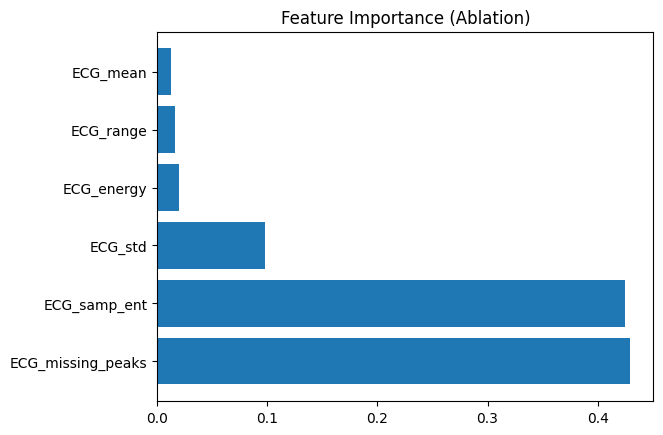

ECG_mean: 0.0125
ECG_std: 0.0981
ECG_range: 0.0160
ECG_energy: 0.0192
ECG_samp_ent: 0.4250
ECG_missing_peaks: 0.4292


In [18]:
# Feature Importance (Ablation)
# Mostrar la importancia de cada característica en el modelo XGBoost Clasificador
importances_clf2 = model_clf2.feature_importances_
feature_names2 = X_train_new.columns
# Sort for top 10
sorted_idx = np.argsort(importances_clf2)[::-1][:10]
plt.barh(feature_names2[sorted_idx], importances_clf2[sorted_idx])
plt.title("Feature Importance (Ablation)")
plt.show()

# Imprimir las importancias numéricamente
for name, imp in zip(feature_names2, importances_clf2):
    print(f"{name}: {imp:.4f}")